# Post-quench $G(t,0)$ decay, across $\beta$ and tuned kernel $(\delta_*,\Lambda)$

Scans `kbe_runs/` under both `syk_sims` and `local_runs` for `kbe-one` outputs, keeps the best-resolution run per $(\beta,\,\delta_*,\,\Lambda)$, and plots how the quench-time correlator $G(t,0)$ decays after the quench at $t=0$.


Since only the post-quench block `Ggt_post` ($t_1\ge0$, all $t_2$) is saved -- the pre-quench $(t_1,t_2\le0)$ block is exactly the known, translation-invariant equilibrium solution $G(t_1,t_2)=G_{\rm eq}(t_1-t_2)$ -- the diagonal stencil below reads from a small helper that stitches `Ggt_post` (for $t_1\ge0$) together with the one-time equilibrium trace `Ggt_eq_t` (for $t_1<0$), so it works seamlessly across the quench.

In [48]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    from IPython.display import display
except Exception:
    display = print

plt.rcParams.update({
    "figure.figsize": (8.2, 5.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## Choices

`BETA_KEEP` / `DELTA_CUTOFF_KEEP` mirror `syk_realtime_kernel.ipynb`'s `beta_keep_kernel` / `delta_cutoff_keep`. The values below match what's actually on disk right now (a handful of validation runs from `run_local_kbe.sh` / early sweep testing, not a full production sweep yet) -- widen them once more `kbe-one` runs exist.

In [49]:
ROOTS = [
    Path("/Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/kbe_runs"),
    Path("/Users/meabh/Desktop/CC Quench States/SYK Quenches/local_runs/kbe_runs"),
]

J4_keep = 1.0  # this notebook assumes a pure relaxation quench, J4_i == J4_f == J4_keep
EVOLUTION_KERNEL_LAMBDA = 0.0  # kernel-free evolution (matches run_local_kbe.sh's production convention)

BETA_KEEP = [12, 24,36,48]

EQ_KERNEL_LAMBDA = 0.005

# (delta_star, Lambda) pairs -- must stay paired, not looped independently
# (see submit_eq.sh's comment on this exact footgun).
DELTA_CUTOFF_KEEP = [
    #(-0.043936, 0.65),
    (-0.053648, 0.75),
]

## Scan `kbe_runs/` and build a manifest

In [50]:
REQUIRED_KEYS = {"Ggt_post", "t_row_post", "t_col_all", "n0", "t_eq", "Ggt_eq_t"}


def scan_kbe_runs(roots):
    rows = []
    for root in roots:
        if not root.exists():
            continue
        for f in sorted(root.glob("**/*.npz")):
            if f.name.endswith(".ckpt.npz"):
                continue
            try:
                with np.load(f, allow_pickle=True) as data:
                    if "metadata_json" not in data.files:
                        continue
                    meta = json.loads(str(data["metadata_json"]))
                    if meta.get("kind") != "kbe" or not REQUIRED_KEYS.issubset(data.files):
                        continue
            except Exception as e:
                print(f"Skipping {f}: {e}")
                continue

            rows.append({
                "filename": str(f),
                "root": str(root),
                "J4_i": float(meta["J4_i"]),
                "J4_f": float(meta["J4_f"]),
                "beta": float(meta["beta"]),
                "dt": float(meta["dt"]),
                "corr_tol": float(meta["corr_tol"]),
                "kernel_lambda": float(meta["kernel_lambda"]),
                "eq_kernel_lambda": float(meta["eq_kernel_lambda"]),
                "eq_kernel_c": float(meta["eq_kernel_c"]),
                "eq_kernel_cutoff": float(meta["eq_kernel_cutoff"]),
                "t_pre_factor": None if meta.get("t_pre_factor") is None else float(meta["t_pre_factor"]),
                "t_post_factor": None if meta.get("t_post_factor") is None else float(meta["t_post_factor"]),
                "n_corr": int(meta["n_corr"]),
            })
    return pd.DataFrame(rows)


df_all = scan_kbe_runs(ROOTS)
print(f"Found {len(df_all)} kbe-one run(s) with the current post-quench-block schema.")

Found 32 kbe-one run(s) with the current post-quench-block schema.


## Filter to the chosen $(\beta,\delta_*,\Lambda)$ and keep the best resolution

Ranking: smallest `corr_tol`, then smallest `dt`, one run kept per $(\beta,\delta_*,\Lambda)$.

In [51]:
def selected_pairs(delta, cutoff, delta_keep, cutoff_keep, atol=1e-6):
    delta = np.asarray(delta, dtype=float)
    cutoff = np.asarray(cutoff, dtype=float)
    mask = np.zeros(len(delta), dtype=bool)
    for d, c in zip(delta_keep, cutoff_keep):
        mask |= np.isclose(delta, d, atol=atol) & np.isclose(cutoff, c, atol=atol)
    return mask


delta_keep, cutoff_keep = zip(*DELTA_CUTOFF_KEEP)

# Both signs of eq_kernel_lambda are kept here (not just +EQ_KERNEL_LAMBDA):
# the G(t,0)/O0/O1 plots below use only the +lambda branch, but D_lambda
# needs both signs paired up.
mask = (
    np.isclose(df_all["J4_i"], J4_keep)
    & np.isclose(df_all["J4_f"], J4_keep)
    & np.isclose(df_all["kernel_lambda"], EVOLUTION_KERNEL_LAMBDA)
    & np.isclose(np.abs(df_all["eq_kernel_lambda"]), abs(EQ_KERNEL_LAMBDA))
    & df_all["beta"].isin(BETA_KEEP)
    & selected_pairs(df_all["eq_kernel_c"], df_all["eq_kernel_cutoff"], delta_keep, cutoff_keep)
)
df_filtered = df_all[mask].copy()

df_best = (
    df_filtered
    .sort_values(["corr_tol", "dt"], ascending=[True, True])
    .drop_duplicates(["beta", "eq_kernel_lambda", "eq_kernel_c", "eq_kernel_cutoff"], keep="first")
    .sort_values(["eq_kernel_cutoff", "beta", "eq_kernel_lambda"])
    .reset_index(drop=True)
)

print(f"Kept {len(df_best)} run(s):")
display(df_best[["beta", "eq_kernel_lambda", "eq_kernel_c", "eq_kernel_cutoff", "dt", "corr_tol", "root"]])

missing = [
    (beta, d, c)
    for beta in BETA_KEEP
    for d, c in DELTA_CUTOFF_KEEP
    if not (
        (np.isclose(df_best["beta"], beta))
        & np.isclose(df_best["eq_kernel_c"], d)
        & np.isclose(df_best["eq_kernel_cutoff"], c)
    ).any()
]
if missing:
    print("No matching run found for:")
    for beta, d, c in missing:
        print(f"  beta={beta:g}, delta={d:g}, Lambda={c:g}")

Kept 8 run(s):


,beta,eq_kernel_lambda,eq_kernel_c,eq_kernel_cutoff,dt,corr_tol,root
0,12.0,-0.005,-0.053648,0.75,0.025,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
1,12.0,0.005,-0.053648,0.75,0.025,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
2,24.0,-0.005,-0.053648,0.75,0.050,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
3,24.0,0.005,-0.053648,0.75,0.050,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
4,36.0,-0.005,-0.053648,0.75,0.050,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
5,36.0,0.005,-0.053648,0.75,0.050,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
6,48.0,-0.005,-0.053648,0.75,0.050,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...
7,48.0,0.005,-0.053648,0.75,0.050,1.000000e-12,/Users/meabh/Desktop/CC Quench States/SYK Quen...


## Load $G(t,0)$ and $O_0(t)$, $O_1(t)$

In [52]:
def build_G_lookup(t_row_post, t_col_all, Ggt_post, t_eq, Ggt_eq_t, dt):
    """G(t1, t2), valid for any t1, t2 on the run's dt grid.

    t1 >= 0 reads directly off the saved post-quench block. t1 < 0 uses
    G(t1, t2) = G_eq(t1 - t2) (equilibrium, translation-invariant), since
    the pre-quench block was never stored.
    """
    t0_row, t0_col = t_row_post[0], t_col_all[0]
    n_row, n_col = Ggt_post.shape

    def G_eq(tau):
        tau = np.asarray(tau, dtype=float)
        return np.interp(tau, t_eq, Ggt_eq_t.real) + 1j * np.interp(tau, t_eq, Ggt_eq_t.imag)

    def G(t1, t2):
        if t1 >= -1e-9:
            i = min(max(int(round((t1 - t0_row) / dt)), 0), n_row - 1)
            j = min(max(int(round((t2 - t0_col) / dt)), 0), n_col - 1)
            return Ggt_post[i, j]
        return G_eq(t1 - t2)

    return G


def load_quench_run(filename):
    with np.load(filename, allow_pickle=True) as data:
        meta = json.loads(str(data["metadata_json"]))
        t_row_post = np.asarray(data["t_row_post"], dtype=float)
        t_col_all = np.asarray(data["t_col_all"], dtype=float)
        Ggt_post = np.asarray(data["Ggt_post"], dtype=complex)
        n0 = int(np.asarray(data["n0"]).item())
        t_eq = np.asarray(data["t_eq"], dtype=float)
        Ggt_eq_t = np.asarray(data["Ggt_eq_t"], dtype=complex)

    dt = float(np.nanmedian(np.diff(t_col_all)))

    # G(t, 0): direct for t>=0, reconstructed from equilibrium for t<0.
    G_post = Ggt_post[:, n0]
    t_pre = t_col_all[t_col_all < 0]
    G_pre = np.interp(t_pre, t_eq, Ggt_eq_t.real) + 1j * np.interp(t_pre, t_eq, Ggt_eq_t.imag)
    t_Gt0 = np.concatenate([t_pre, t_row_post])
    G_t0 = np.concatenate([G_pre, G_post])
    order = np.argsort(t_Gt0)
    t_Gt0, G_t0 = t_Gt0[order], G_t0[order]

    # O0(t), O1(t) via the diagonal 3-point stencil, stitched across t=0.
    G = build_G_lookup(t_row_post, t_col_all, Ggt_post, t_eq, Ggt_eq_t, dt)
    c_d1 = np.array([-0.5, 0.0, 0.5]) / dt
    c_d2 = np.array([1.0, -2.0, 1.0]) / dt**2

    t_O = t_col_all[1:-1]
    O0 = np.empty(len(t_O), dtype=complex)
    O1 = np.empty(len(t_O), dtype=complex)
    for k, t in enumerate(t_O):
        patch = np.array([
            [G(t - dt, t - dt), G(t - dt, t), G(t - dt, t + dt)],
            [G(t,      t - dt), G(t,      t), G(t,      t + dt)],
            [G(t + dt, t - dt), G(t + dt, t), G(t + dt, t + dt)],
        ])
        d10 = np.einsum("i,i->", c_d1, patch[:, 1])
        d01 = np.einsum("i,i->", c_d1, patch[1, :])
        O0[k] = 0.5 * (d10 - d01)

        d21 = np.einsum("i,j,ij->", c_d2, c_d1, patch)
        d12 = np.einsum("i,j,ij->", c_d1, c_d2, patch)
        O1[k] = -0.5 * (d21 - d12)

    return {
        "meta": meta,
        "t_Gt0": t_Gt0, "G_t0": G_t0,
        "t_O": t_O, "O0": O0, "O1": O1,
        "G_lookup": G,
    }


runs = [dict(row) | load_quench_run(row["filename"]) for _, row in df_best.iterrows()]
print(f"Loaded {len(runs)} run(s).")

# G(t,0)/O0/O1 below only show a single (+lambda) branch; D_lambda further
# down uses `runs` directly since it needs both signs paired up.
runs_plus = [r for r in runs if r["eq_kernel_lambda"] > 0]

Loaded 8 run(s).


## Colour helper

One sequential colormap per $(\delta_*,\Lambda)$ tuple, shaded by $\beta$ -- same convention as `syk_realtime_kernel.ipynb`.

In [53]:
_CMAPS = ["Blues", "Oranges", "Greens", "Purples", "Greys"]


def tuple_index(cutoff):
    for i, (_, c) in enumerate(DELTA_CUTOFF_KEEP):
        if np.isclose(cutoff, c):
            return i
    return 0


def colour_for(run, betas_this_tuple):
    cmap = plt.colormaps[_CMAPS[tuple_index(run["eq_kernel_cutoff"]) % len(_CMAPS)]]
    betas_sorted = sorted(betas_this_tuple)
    i = betas_sorted.index(run["beta"])
    shade = 0.35 + 0.55 * i / max(len(betas_sorted) - 1, 1)
    return cmap(shade)


def legend_handles():
    handles = []
    for i, (d, c) in enumerate(DELTA_CUTOFF_KEEP):
        cmap = plt.colormaps[_CMAPS[i % len(_CMAPS)]]
        handles.append(Line2D([0], [0], color=cmap(0.75), lw=2, label=rf"$\delta_*={d:g},\ \Lambda={c:g}$"))
    return handles

## $|G(t,0)|$ decay after the quench

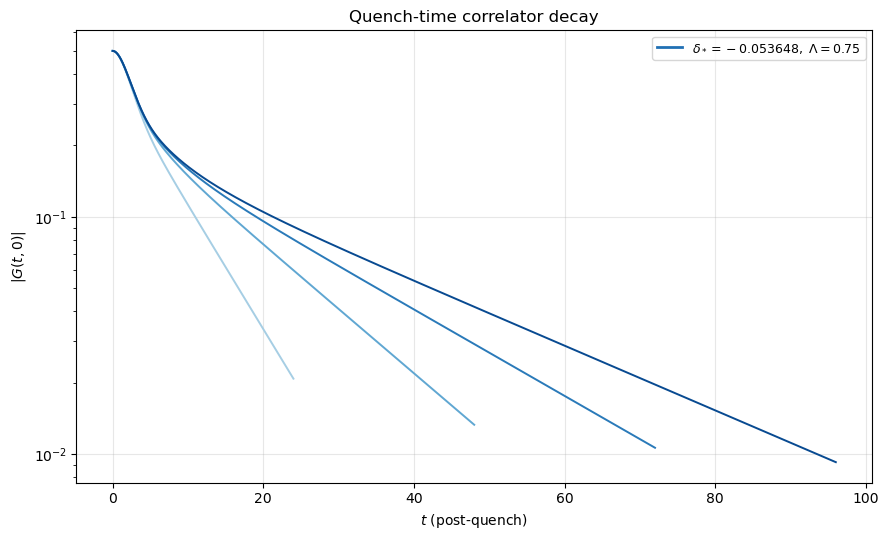

In [54]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for run in runs_plus:
    betas_this_tuple = [r["beta"] for r in runs_plus if np.isclose(r["eq_kernel_cutoff"], run["eq_kernel_cutoff"])]
    keep = run["t_Gt0"] >= 0
    ax.plot(
        run["t_Gt0"][keep], np.abs(run["G_t0"][keep]),
        lw=1.4, color=colour_for(run, betas_this_tuple),
    )

ax.set_xlabel(r"$t$ (post-quench)")
ax.set_ylabel(r"$|G(t,0)|$")
ax.set_yscale("log")
ax.set_title("Quench-time correlator decay")
ax.legend(handles=legend_handles(), fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

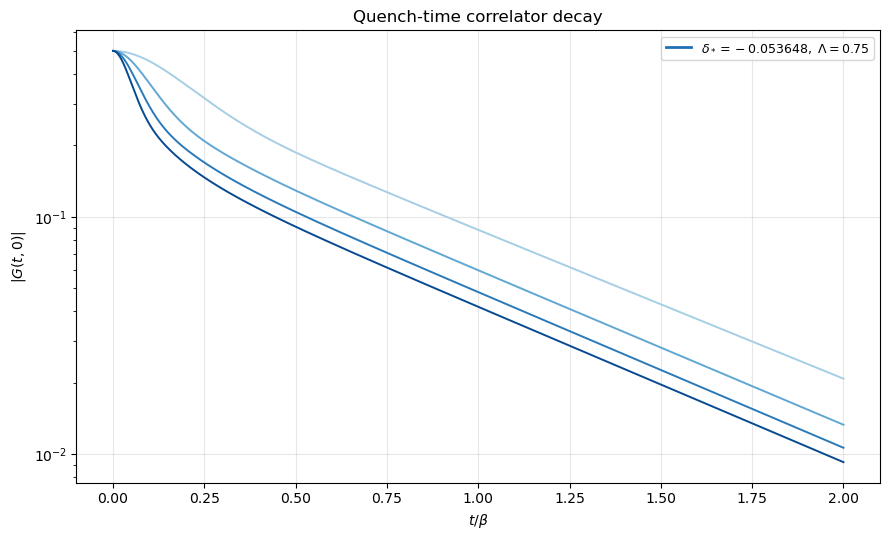

In [55]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for run in runs_plus:
    betas_this_tuple = [r["beta"] for r in runs_plus if np.isclose(r["eq_kernel_cutoff"], run["eq_kernel_cutoff"])]
    keep = run["t_Gt0"] >= 0
    ax.plot(
        run["t_Gt0"][keep]/run["beta"], np.abs(run["G_t0"][keep]),
        lw=1.4, color=colour_for(run, betas_this_tuple),
    )

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|G(t,0)|$")
ax.set_yscale("log")
ax.set_title("Quench-time correlator decay")
ax.legend(handles=legend_handles(), fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Fixed relative-time trace $G^>(T+\tau/2,\,T-\tau/2)$ vs centre time $T$

For a short relative time $\tau$ (set per $\beta$ below), plots $G^>(T+\tau/2,\,T-\tau/2)$ as a function of the centre time $T$ -- same convention as `analyse_kbe_runs_tidied.ipynb`'s fixed-$\tau$ traces. For $T+\tau/2<0$ (fully pre-quench) this is exactly $G_{\rm eq}(\tau)$, constant in $T$ by time-translation invariance; the deviation from that flat baseline once $T$ crosses into the post-quench region shows the quench's effect directly.

In [56]:
# tau for each beta -- edit freely; any beta not listed falls back to DEFAULT_TAU.
DEFAULT_TAU = 0.2
TAU_BY_BETA = {
    12: 0.2,
    24: 0.2,
    36: 0.2,
    48: 0.2,
}

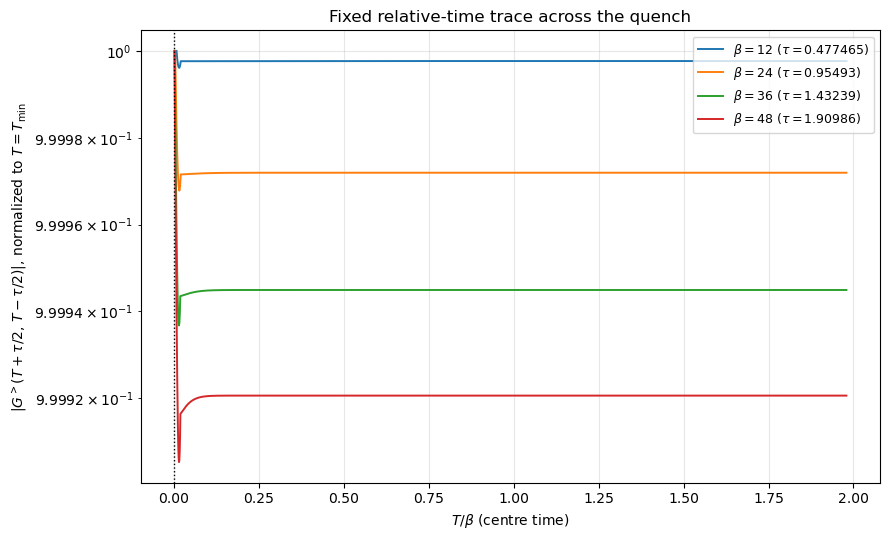

In [57]:
betas_sorted = sorted({r["beta"] for r in runs_plus})
beta_colors = {b: plt.colormaps["tab10"](i % 10) for i, b in enumerate(betas_sorted)}

fig, ax = plt.subplots(figsize=(9, 5.5))

for run in runs_plus:
    beta = run["beta"]
    tau = beta/8/np.pi
    G = run["G_lookup"]

    dt = float(np.nanmedian(np.diff(run["t_Gt0"])))
    t_min, t_max = 0.1, run["t_Gt0"][-1]
    # Margin applied against the run's *actual* stored range (so T+/-tau/2
    # never reads outside it), not against the display window t_min/t_max
    # -- otherwise T_grid starts at t_min+tau/2 instead of t_min itself.
    data_min, data_max = run["t_Gt0"][0], run["t_Gt0"][-1]
    T_grid = np.arange(max(t_min, data_min + tau / 2), min(t_max, data_max - tau / 2), dt)

    G_fixed_tau = np.array([G(T + tau / 2, T - tau / 2) for T in T_grid])

    label = rf"$\beta={beta:g}$"
    if len(DELTA_CUTOFF_KEEP) > 1:
        label += rf", $\Lambda={run['eq_kernel_cutoff']:g}$"
    label += rf" ($\tau={tau:g}$)"

    ax.plot(T_grid/beta, np.abs(G_fixed_tau)/np.abs(G_fixed_tau[0]), lw=1.4, color=beta_colors[beta], label=label)

ax.axvline(0.0, color="black", lw=1, ls=":")
ax.set_xlabel(r"$T/\beta$ (centre time)")
ax.set_ylabel(r"$|G^>(T+\tau/2,\,T-\tau/2)|$, normalized to $T=T_{\min}$")
ax.set_yscale("log")
ax.set_title("Fixed relative-time trace across the quench")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## $D_{\rm odd}(t,0)$ after the quench

The odd-in-$\lambda$ response, copied directly from `syk_realtime_kernel.ipynb`'s 25th executed cell (`build_kernel_odd_response`):
$$
D_{\rm odd}(t,0) = \frac{G_{+\lambda}(t,0) - G_{-\lambda}(t,0)}{2\lambda\, G_c(t,0)},
$$
using that same notebook's `Gc_complex(t,\beta,J)` for $G_c$ (the free/conformal correlator, $\Delta=1/4$). This needs a matched $\pm\lambda$ pair at the same $(\beta,\delta_*,\Lambda)$; pairs missing the other sign are reported below and simply skipped. $t=0$ itself is excluded since $G_c(0,0)$ has a pole there (same short-time singularity the equilibrium notebook works around with its `uv_t_plot_min` cutoffs).

In [120]:
Delta = 1 / 4
def Gc_complex(t, beta, J):
    amplitude = (
        (0.5 - Delta)
        * np.tan(np.pi * Delta)
        / (np.pi * J**2)
    ) ** Delta

    envelope = amplitude * (
        np.pi / (beta * np.sinh(np.pi * t / beta))
    ) ** (2 * Delta)

    # G_c^>(-t), matching G(0,t)=G_eq(-t).
    return envelope * (
        np.sin(np.pi * Delta)
        - 1j * np.cos(np.pi * Delta)
    )


def pair_key(run):
    return (run["beta"], round(run["eq_kernel_c"], 6), round(run["eq_kernel_cutoff"], 6))


pairs = {}
for r in runs:
    pairs.setdefault(pair_key(r), {})[float(np.sign(r["eq_kernel_lambda"]))] = r

D_odd_runs = []
missing_pairs = []
for key, sides in pairs.items():
    if 1.0 in sides and -1.0 in sides:
        r_plus, r_minus = sides[1.0], sides[-1.0]
        t = r_plus["t_Gt0"]
        lam = abs(r_plus["eq_kernel_lambda"])
        J = r_plus["J4_i"]
        beta = r_plus["beta"]

        G_minus_on_plus = (
            np.interp(t, r_minus["t_Gt0"], r_minus["G_t0"].real)
            + 1j * np.interp(t, r_minus["t_Gt0"], r_minus["G_t0"].imag)
        )
        D_odd = (r_plus["G_t0"] - G_minus_on_plus) / (2 * lam * Gc_complex(t, beta, J))
        D_odd_runs.append({
            "beta": beta,
            "eq_kernel_c": r_plus["eq_kernel_c"],
            "eq_kernel_cutoff": r_plus["eq_kernel_cutoff"],
            "t": t, "D_odd": D_odd,
        })
    else:
        missing_pairs.append(key)

print(f"Paired {len(D_odd_runs)} beta/kernel combo(s) for D_odd.")
if missing_pairs:
    print("Missing the other sign (no +/-lambda pair) for:")
    for beta, d, c in missing_pairs:
        print(f"  beta={beta:g}, delta={d:g}, Lambda={c:g}")

Paired 4 beta/kernel combo(s) for D_odd.


/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_2781/2857708700.py:10: RuntimeWarning: divide by zero encountered in divide
  np.pi / (beta * np.sinh(np.pi * t / beta))
/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_2781/2857708700.py:9: RuntimeWarning: invalid value encountered in sqrt
  envelope = amplitude * (
/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_2781/2857708700.py:42: RuntimeWarning: invalid value encountered in multiply
  D_odd = (r_plus["G_t0"] - G_minus_on_plus) / (2 * lam * Gc_complex(t, beta, J))
/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_2781/2857708700.py:42: RuntimeWarning: invalid value encountered in divide
  D_odd = (r_plus["G_t0"] - G_minus_on_plus) / (2 * lam * Gc_complex(t, beta, J))


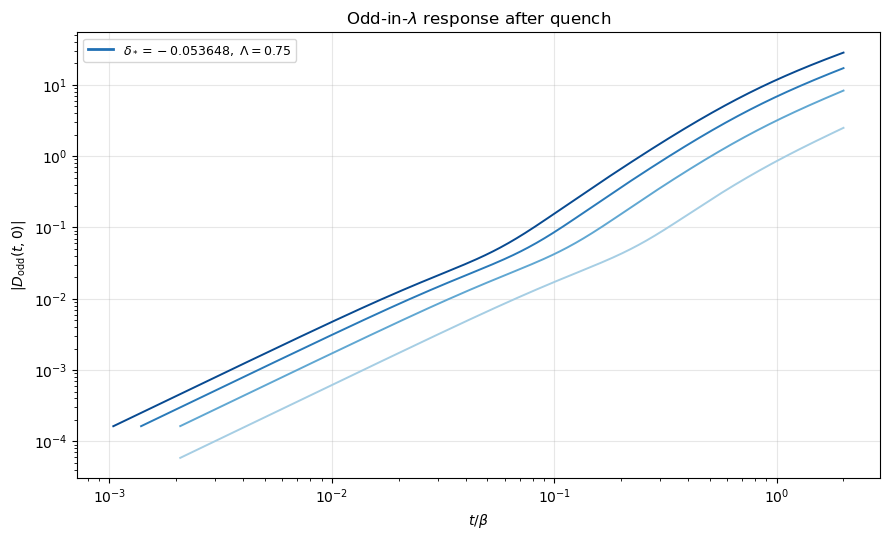

In [121]:
fig, ax = plt.subplots(figsize=(9, 5.5))

betas_by_cutoff = {}
for run in D_odd_runs:
    betas_by_cutoff.setdefault(run["eq_kernel_cutoff"], []).append(run["beta"])

for run in D_odd_runs:
    D_odd_abs = np.abs(run["D_odd"])
    keep = (run["t"] > 0) & (D_odd_abs >= 1e-14)  # t=0 excluded: Gc_complex has a pole there; drop |D_odd| below noise floor
    ax.plot(
        run["t"][keep]/run['beta'], D_odd_abs[keep],
        lw=1.4, color=colour_for(run, betas_by_cutoff[run["eq_kernel_cutoff"]]),
    )

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|D_{\rm odd}(t,0)|$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(r"Odd-in-$\lambda$ response after quench")
ax.legend(handles=legend_handles(), fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not D_odd_runs:
    print("No +/-lambda pairs available yet.")

## Fixed relative-time $D_{\rm odd}(T+\tau/2,\,T-\tau/2)$ vs centre time $T$

Same fixed-$\tau$ centre-time construction as the bare-$G$ trace above, applied to the odd-in-$\lambda$ response instead: for each matched $\pm\lambda$ pair,
$$
D_{\rm odd}(T+\tfrac\tau2,\,T-\tfrac\tau2) = \frac{G_{+\lambda}(T+\tfrac\tau2,\,T-\tfrac\tau2) - G_{-\lambda}(T+\tfrac\tau2,\,T-\tfrac\tau2)}{2\lambda\, G_c(\tau)},
$$
normalizing by $G_c$ at the *fixed* separation $\tau$ (not at $T$), since $G_c$ is itself translation-invariant. Missing $\pm\lambda$ pairs are skipped, same as the diagonal $D_{\rm odd}(t,0)$ plot.

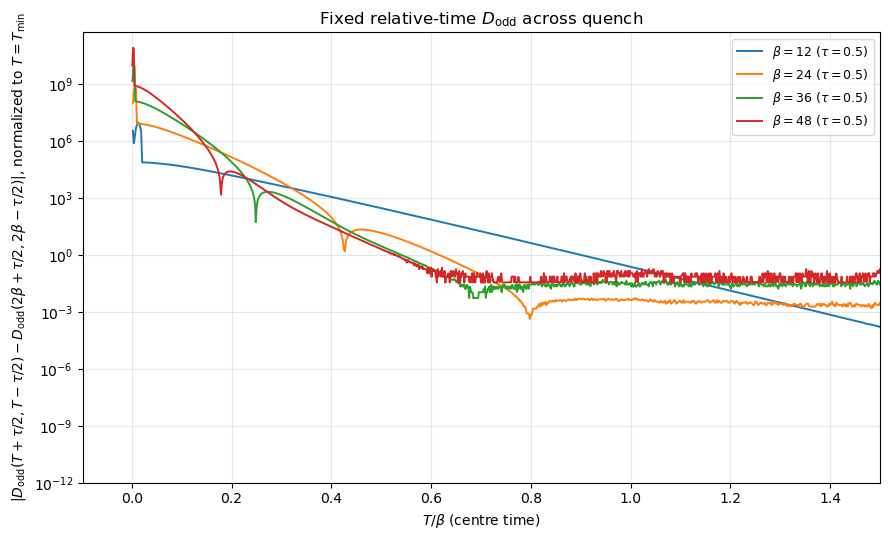

In [122]:
fig, ax = plt.subplots(figsize=(9, 5.5))

any_pair = False
for key, sides in pairs.items():
    if not (1.0 in sides and -1.0 in sides):
        continue
    any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]
    lam = abs(r_plus["eq_kernel_lambda"])
    tau = 0.5 #beta / 8 / np.pi

    G_plus, G_minus = r_plus["G_lookup"], r_minus["G_lookup"]

    dt = float(np.nanmedian(np.diff(r_plus["t_Gt0"])))
    t_min, t_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    # Margin applied against the run's *actual* stored range, not against
    # the display window t_min/t_max -- see the bare-G trace cell above.
    data_min, data_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    T_grid = np.arange(max(t_min, data_min + tau / 2), min(t_max, data_max - tau / 2), dt)

    G_plus_fixed_tau = np.array([G_plus(T + tau / 2, T - tau / 2) for T in T_grid])
    G_minus_fixed_tau = np.array([G_minus(T + tau / 2, T - tau / 2) for T in T_grid])
    D_odd_fixed_tau = (G_plus_fixed_tau - G_minus_fixed_tau) / (2 * lam * Gc_complex(tau, beta, J))

    label = rf"$\beta={beta:g}$"
    if len(DELTA_CUTOFF_KEEP) > 1:
        label += rf", $\Lambda={r_plus['eq_kernel_cutoff']:g}$"
    label += rf" ($\tau={tau:g}$)"

    y_vals = np.abs(1 - np.abs(D_odd_fixed_tau / D_odd_fixed_tau[-1]))
    #y_vals = np.abs(np.abs(D_odd_fixed_tau ))
    keep = (y_vals >= 1e-13) & (T_grid>0)  # drop |D_odd| below noise floor
    ax.plot(
        T_grid[keep]/beta,beta**(2*3.77-1) *y_vals[keep],
        lw=1.4, color=beta_colors[beta], label=label,
    )
    #ax.plot(T_grid[keep]/beta, np.exp(-T_grid[keep])/100,lw=1.4, color=beta_colors[beta], label="e^{-Jt}",ls='--',)

#ax.plot(np.linspace(0.3,1,20), np.exp(-2*2*np.pi*np.linspace(0.3,1,20))/1000000,color="purple", lw=1, ls=":",label = r'$e^{-2\pi h_0 t/\beta}$')
#ax.plot(np.linspace(0.3,1,20), np.exp(-2*3.77*np.pi*np.linspace(0.1,1,20))/5000000,color="black", lw=1, ls=":",label = r'$e^{-2\pi h_1t/\beta}$')

ax.set_xlabel(r"$T/\beta$ (centre time)")
ax.set_ylabel(r"$|D_{\rm odd}(T+\tau/2,T-\tau/2)-D_{\rm odd}(2\beta+\tau/2,2\beta-\tau/2)|$, normalized to $T=T_{\min}$")
ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlim((None,1.5))
ax.set_ylim((1e-12, None))#0.00000005))
ax.set_title(r"Fixed relative-time $D_{\rm odd}$ across quench")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not any_pair:
    print("No +/-lambda pairs available yet.")

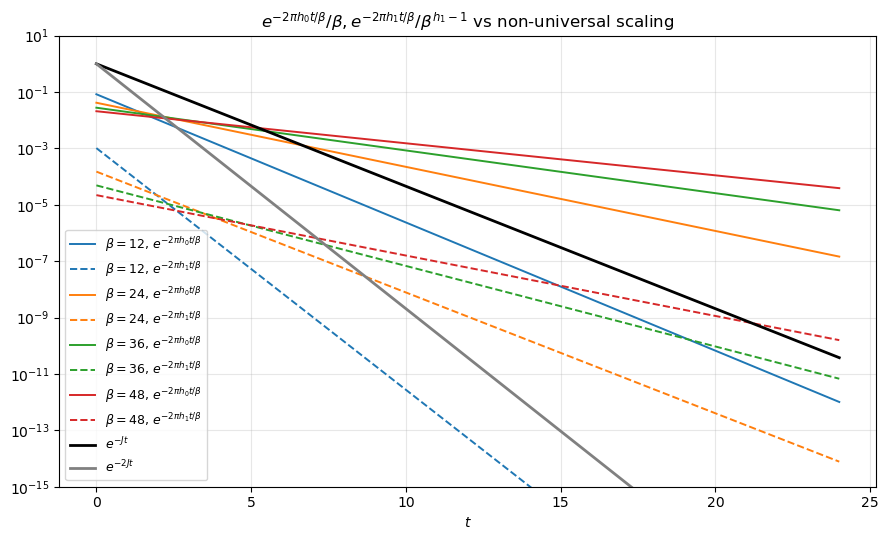

In [123]:
fig, ax = plt.subplots(figsize=(9, 5.5))
tgrid= np.linspace(0,24,100)

any_pair = False
for key, sides in pairs.items():
    if not (1.0 in sides and -1.0 in sides):
        continue
    any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]


    ax.plot(
        tgrid, np.exp(-4*np.pi*tgrid/beta)/beta ,
        lw=1.4, color=beta_colors[beta], label=rf"$\beta=${beta:1g}"+r", $e^{-2\pi h_0 t/\beta }$",
    )

    ax.plot(
            tgrid, np.exp(-2*3.77*np.pi*tgrid/beta)/beta**(3.77-1) ,
            lw=1.4, color=beta_colors[beta], label=rf"$\beta=${beta:1g}"+r", $e^{-2\pi h_1 t/\beta }$",ls='--',
        )

ax.plot(tgrid, np.exp(-tgrid),color="black", lw=2 ,label = r'$e^{-J t}$')
ax.plot(tgrid, np.exp(-2*tgrid),color="gray", lw=2, label = r'$e^{-2J t}$')

ax.set_xlabel(r"$t$ ")
ax.set_yscale("log")
ax.set_ylim((10**(-15),10))
#ax.set_xscale("log")
ax.set_title(r"$e^{-2 \pi h_0 t/\beta }/\beta,e^{-2 \pi h_1 t/\beta }/\beta^{h_1-1}$ vs non-universal scaling")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [124]:
np.array([12,18,24,30,36,42,48])/4/np.pi

array([0.95492966, 1.43239449, 1.90985932, 2.38732415, 2.86478898,
       3.3422538 , 3.81971863])

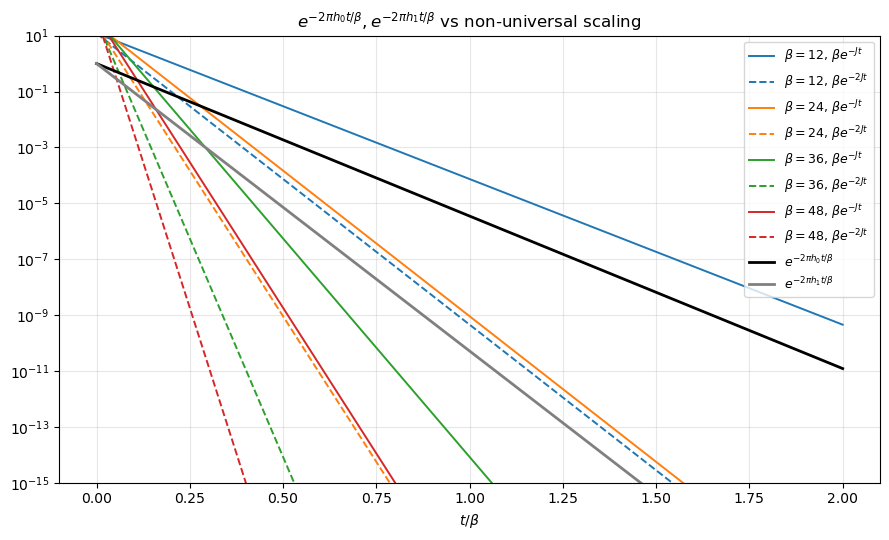

In [125]:
fig, ax = plt.subplots(figsize=(9, 5.5))
xgrid= np.linspace(0,2,100)

any_pair = False
for key, sides in pairs.items():
    if not (1.0 in sides and -1.0 in sides):
        continue
    any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]


    ax.plot(xgrid, beta*np.exp(-xgrid*beta), lw=1.4 ,color=beta_colors[beta], label=rf"$\beta=${beta:1g}"+r", $\beta e^{-J  t }$")
    ax.plot(xgrid, beta*np.exp(-2*xgrid*beta), lw=1.4, color=beta_colors[beta], label=rf"$\beta=${beta:1g}"+r", $\beta e^{-2J t }$",ls='--')

ax.plot(xgrid, np.exp(-4*np.pi*xgrid) ,lw=2, color="black",label=r"$e^{-2\pi h_0 t/\beta }$")

ax.plot(xgrid, np.exp(-2*3.77*np.pi*xgrid) ,lw=2,color="gray",label=r"$e^{-2\pi h_1 t/\beta }$")


ax.set_xlabel(r"$t/\beta$ ")
ax.set_yscale("log")
ax.set_ylim((10**(-15),10))
#ax.set_xscale("log")
ax.set_title(r"$e^{-2 \pi h_0 t/\beta },e^{-2 \pi h_1 t/\beta }$ vs non-universal scaling")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

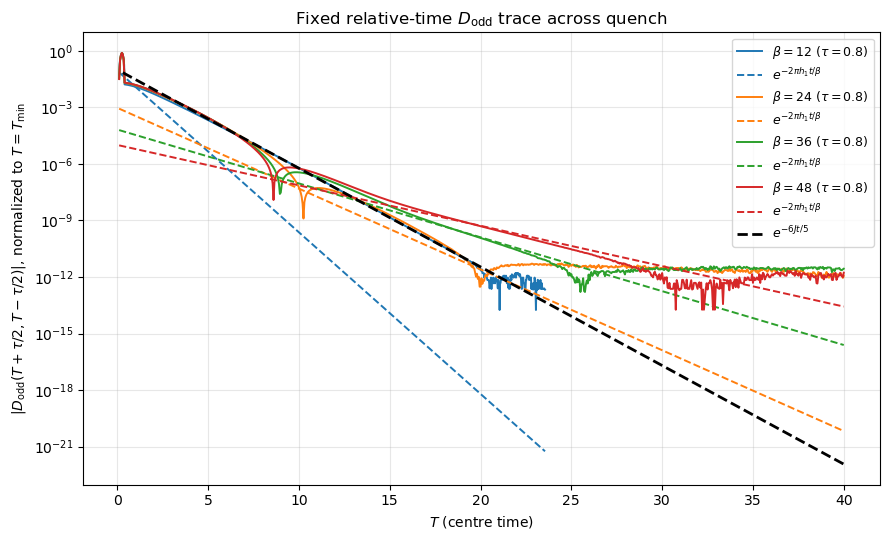

In [130]:
fig, ax = plt.subplots(figsize=(9, 5.5))

any_pair = False
for key, sides in pairs.items():
    if not (1.0 in sides and -1.0 in sides):
        continue
    any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]
    lam = abs(r_plus["eq_kernel_lambda"])
    tau = 0.8 #beta / 8 / np.pi

    G_plus, G_minus = r_plus["G_lookup"], r_minus["G_lookup"]

    dt = float(np.nanmedian(np.diff(r_plus["t_Gt0"])))
    t_min, t_max = 0.1, r_plus["t_Gt0"][-1]
    # Margin applied against the run's *actual* stored range, not against
    # the display window t_min/t_max -- see the bare-G trace cell above.
    data_min, data_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    T_grid = np.arange(max(t_min, data_min + tau / 2), min(t_max, data_max - tau / 2), dt)

    G_plus_fixed_tau = np.array([G_plus(T + tau / 2, T - tau / 2) for T in T_grid])
    G_minus_fixed_tau = np.array([G_minus(T + tau / 2, T - tau / 2) for T in T_grid])
    D_odd_fixed_tau = (G_plus_fixed_tau - G_minus_fixed_tau) / (2 * lam * Gc_complex(tau, beta, J))

    label = rf"$\beta={beta:g}$"
    if len(DELTA_CUTOFF_KEEP) > 1:
        label += rf", $\Lambda={r_plus['eq_kernel_cutoff']:g}$"
    label += rf" ($\tau={tau:g}$)"

    y_vals = np.abs(1 - np.abs(D_odd_fixed_tau / D_odd_fixed_tau[-1]))
    keep = (y_vals >= 1e-14) & (T_grid<=40)  # drop |D_odd| below noise floor
    ax.plot(
        T_grid[keep], y_vals[keep], # - np.exp(-T_grid)/1000) ,
        lw=1.4, color=beta_colors[beta], label=label,
    )
    ax.plot(
            T_grid[keep], 1000000*np.exp(-2*3.77*np.pi*T_grid[keep]/beta)/beta**(2*3.77-1) ,
            lw=1.4, color=beta_colors[beta], label=r"$e^{-2\pi h_1 t/\beta}$", ls="--"
        )

ax.plot(np.linspace(0.3,40,20), np.exp(-np.linspace(0.3,40,20)/0.83)/10,color="black", lw=2, ls="--",label = r'$e^{- 6 J t /5}$')
#ax.plot(np.linspace(0.3,1,20), np.exp(-2*3.77*np.pi*np.linspace(0.3,1,20))/100,color="black", lw=1, ls=":",label = r'$e^{-2\pi h_1t/\beta}$')

ax.set_xlabel(r"$T$ (centre time)")
ax.set_ylabel(r"$|D_{\rm odd}(T+\tau/2,T-\tau/2)|$, normalized to $T=T_{\min}$")
ax.set_yscale("log")
#ax.set_xscale("log")
#ax.set_xlim((0.3,0.9))
#ax.set_ylim((0.00000001,0.001))
ax.set_title(r"Fixed relative-time $D_{\rm odd}$ trace across quench")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not any_pair:
    print("No +/-lambda pairs available yet.")

In [101]:
1/0.83,2*np.pi/24*3.77,2*np.pi/36*3.77,2*np.pi/48*3.77

(1.2048192771084338,
 0.9869836920027932,
 0.6579891280018623,
 0.4934918460013966)

## $D_{\rm odd}(T+\tau/2,\,T-\tau/2)$ vs relative time $\tau$, at fixed centre time $T$

Complementary to the fixed-$\tau$, varying-$T$ traces above: here the centre time $T$ is held fixed (per $\beta$, set below) and $\tau$ varies instead, showing the odd-in-$\lambda$ response's structure in relative time at a single moment. $\tau$ starts just above $0$ since $G_c(\tau)$ has a pole there; the upper end is capped so $T\pm\tau/2$ stays inside the run's actual stored range.

In [65]:
# centre time T for each beta -- edit freely; falls back to DEFAULT_T_FIXED.
DEFAULT_T_FIXED = 0.1
T_FIXED_BY_BETA = {
    12: 1.0,
    24: 1.0,
    36: 1.0,
}

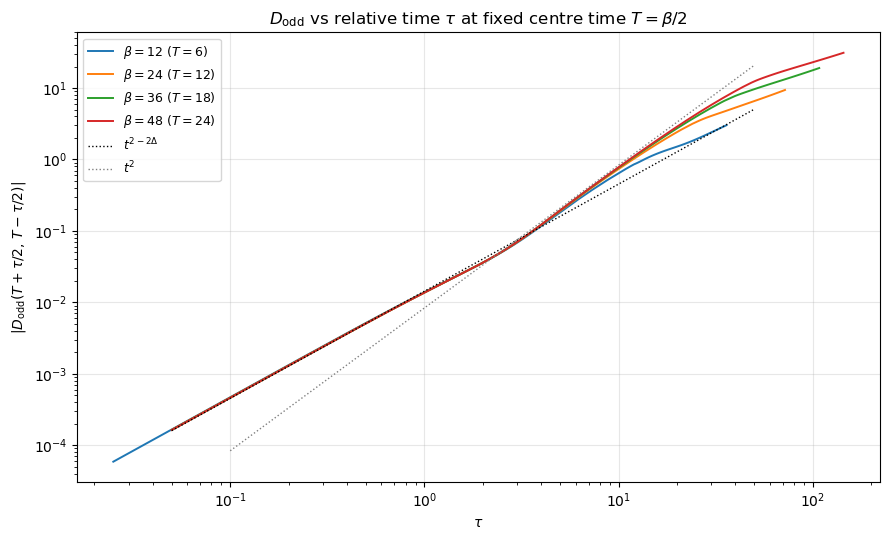

In [66]:
fig, ax = plt.subplots(figsize=(9, 5.5))

any_pair = False
for key, sides in pairs.items():
    if not (1.0 in sides and -1.0 in sides):
        continue
    any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]
    lam = abs(r_plus["eq_kernel_lambda"])
    T_fixed = beta/2 #T_FIXED_BY_BETA.get(beta, DEFAULT_T_FIXED)

    G_plus, G_minus = r_plus["G_lookup"], r_minus["G_lookup"]

    dt = float(np.nanmedian(np.diff(r_plus["t_Gt0"])))
    data_min, data_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    tau_max = 2 * min(T_fixed - data_min, data_max - T_fixed)
    tau_grid = np.arange(dt, tau_max, dt)  # starts just above 0: Gc_complex has a pole at tau=0

    G_plus_fixed_T = np.array([G_plus(T_fixed + tau / 2, T_fixed - tau / 2) for tau in tau_grid])
    G_minus_fixed_T = np.array([G_minus(T_fixed + tau / 2, T_fixed - tau / 2) for tau in tau_grid])
    D_odd_fixed_T = (G_plus_fixed_T - G_minus_fixed_T) / (2 * lam * Gc_complex(tau_grid, beta, J))

    label = rf"$\beta={beta:g}$"
    if len(DELTA_CUTOFF_KEEP) > 1:
        label += rf", $\Lambda={r_plus['eq_kernel_cutoff']:g}$"
    label += rf" ($T={T_fixed:g}$)"

    D_odd_abs = np.abs(D_odd_fixed_T)
    keep = D_odd_abs >= 1e-14  # drop |D_odd| below noise floor
    ax.plot(tau_grid[keep], D_odd_abs[keep], lw=1.4, color=beta_colors[beta], label=label)

ax.plot(np.linspace(0.05,50,20),np.array(np.linspace(0.05,50,20))**(2-1/2)/70,color="black", lw=1, ls=":",label = r'$t^{2-2\Delta}$')
ax.plot(np.linspace(0.1,50,20),np.array(np.linspace(0.1,50,20))**(2)/120,color="gray", lw=1, ls=":",label = r'$t^{2}$')
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$|D_{\rm odd}(T+\tau/2,\,T-\tau/2)|$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(r"$D_{\rm odd}$ vs relative time $\tau$ at fixed centre time $T = \beta/2$")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not any_pair:
    print("No +/-lambda pairs available yet.")

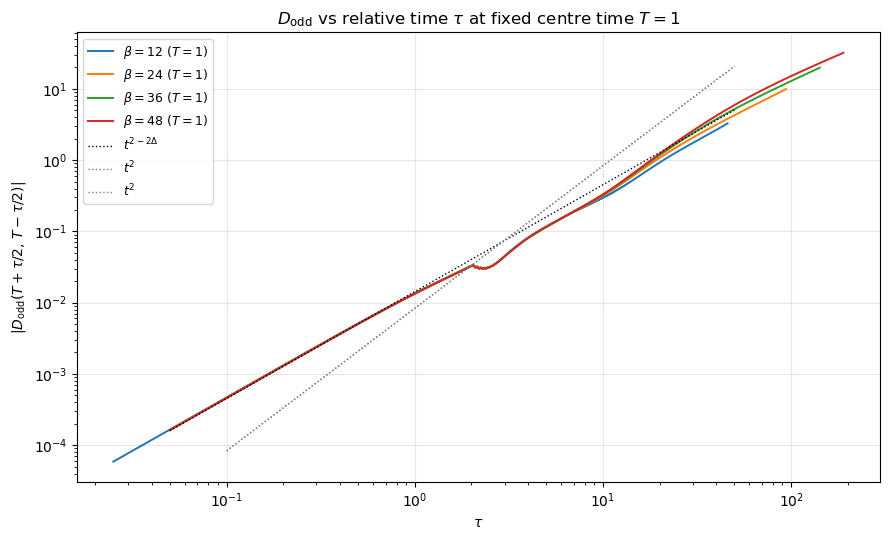

In [69]:
fig, ax = plt.subplots(figsize=(9, 5.5))

any_pair = False
for key, sides in pairs.items():
    if not (1.0 in sides and -1.0 in sides):
        continue
    any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]
    lam = abs(r_plus["eq_kernel_lambda"])
    T_fixed = 1 #beta/np.pi #T_FIXED_BY_BETA.get(beta, DEFAULT_T_FIXED)

    G_plus, G_minus = r_plus["G_lookup"], r_minus["G_lookup"]

    dt = float(np.nanmedian(np.diff(r_plus["t_Gt0"])))
    data_min, data_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    tau_max = 2 * min(T_fixed - data_min, data_max - T_fixed)
    tau_grid = np.arange(dt, tau_max, dt)  # starts just above 0: Gc_complex has a pole at tau=0

    G_plus_fixed_T = np.array([G_plus(T_fixed + tau / 2, T_fixed - tau / 2) for tau in tau_grid])
    G_minus_fixed_T = np.array([G_minus(T_fixed + tau / 2, T_fixed - tau / 2) for tau in tau_grid])
    D_odd_fixed_T = (G_plus_fixed_T - G_minus_fixed_T) / (2 * lam * Gc_complex(tau_grid, beta, J))

    label = rf"$\beta={beta:g}$"
    if len(DELTA_CUTOFF_KEEP) > 1:
        label += rf", $\Lambda={r_plus['eq_kernel_cutoff']:g}$"
    label += rf" ($T={T_fixed:g}$)"

    D_odd_abs = np.abs(D_odd_fixed_T)
    keep = D_odd_abs >= 1e-14  # drop |D_odd| below noise floor
    ax.plot(tau_grid[keep], D_odd_abs[keep], lw=1.4, color=beta_colors[beta], label=label)

ax.plot(np.linspace(0.05,50,20),np.array(np.linspace(0.05,50,20))**(2-1/2)/70,color="black", lw=1, ls=":",label = r'$t^{2-2\Delta}$')
ax.plot(np.linspace(0.1,50,20),np.array(np.linspace(0.1,50,20))**(2)/120,color="gray", lw=1, ls=":",label = r'$t^{2}$')
ax.plot(np.linspace(0.1,50,20),np.array(np.linspace(0.1,50,20))**(2)/120,color="gray", lw=1, ls=":",label = r'$t^{2}$')
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$|D_{\rm odd}(T+\tau/2,\,T-\tau/2)|$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(r"$D_{\rm odd}$ vs relative time $\tau$ at fixed centre time $T = 1$")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not any_pair:
    print("No +/-lambda pairs available yet.")

## Benchmarking: $D_{\rm odd}(t,0)$ vs. KBE solver settings ($\beta=12$)

Loads *every* matching `kbe-one` run at a fixed $\beta$ and $(\delta_*,\Lambda)$ pair -- unlike
the `df_best` selection above, this does **not** collapse to one run per $(\beta,\delta_*,\Lambda)$,
so different `KBE_DT`, `T_POST_FACTOR`, `CORR_TOL`, `N_CORR`, `J4` values (e.g. from repeated
`run_local_kbe.sh` runs with those knobs edited) all show up as separate overlaid curves. Useful
for eyeballing solver convergence: curves that sit on top of each other are converged in that
parameter; curves that visibly separate are not.

Each curve still needs a matched $+\lambda/-\lambda$ pair *at the same full parameter tuple*
(including `dt`, `corr_tol`, etc.) -- runs missing their sign partner are reported and skipped.

In [144]:
BENCH_BETA = 12.0
BENCH_DELTA_CUTOFF = DELTA_CUTOFF_KEEP[0]  # (delta_star, Lambda_factor); must be a tuned pair
BENCH_EQ_KERNEL_LAMBDA = EQ_KERNEL_LAMBDA
BENCH_EVOLUTION_KERNEL_LAMBDA = EVOLUTION_KERNEL_LAMBDA

# Solver-setting values to drop from the benchmark overlay below -- e.g. abandoned
# dt / t_post_factor / n_corr variants that would otherwise clutter the plot. Leave a
# list empty to keep every value on disk for that setting.
BENCH_EXCLUDE_DT = []             # e.g. [0.5, 0.1]
BENCH_EXCLUDE_T_POST_FACTOR = []  # e.g. [1.0]
BENCH_EXCLUDE_N_CORR = []         # e.g. [50]

bench_delta, bench_cutoff = BENCH_DELTA_CUTOFF


def _not_excluded(series, excluded, atol=1e-9):
    """Boolean mask: True where series is NOT close to any value in excluded."""
    if not excluded:
        return np.ones(len(series), dtype=bool)
    series = series.astype(float)
    hit = np.zeros(len(series), dtype=bool)
    for v in excluded:
        hit |= np.isclose(series, float(v), atol=atol)
    return ~hit


# No dedup by (beta, eq_kernel_c, eq_kernel_cutoff) here -- keep every
# (dt, t_post_factor, corr_tol, n_corr, J4) variant on disk for this beta/pair,
# except whatever's listed in BENCH_EXCLUDE_* above.
bench_mask = (
    np.isclose(df_all["beta"], BENCH_BETA)
    & np.isclose(df_all["J4_i"], df_all["J4_f"])  # pure relaxation quench
    & np.isclose(df_all["kernel_lambda"], BENCH_EVOLUTION_KERNEL_LAMBDA)
    & np.isclose(np.abs(df_all["eq_kernel_lambda"]), abs(BENCH_EQ_KERNEL_LAMBDA))
    & np.isclose(df_all["eq_kernel_c"], bench_delta, atol=1e-6)
    & np.isclose(df_all["eq_kernel_cutoff"], bench_cutoff, atol=1e-6)
    & _not_excluded(df_all["dt"], BENCH_EXCLUDE_DT)
    & _not_excluded(df_all["t_post_factor"], BENCH_EXCLUDE_T_POST_FACTOR)
    & _not_excluded(df_all["n_corr"], BENCH_EXCLUDE_N_CORR)
)
df_bench = df_all[bench_mask].copy().reset_index(drop=True)

### Load and pair by the full solver-parameter tuple

In [145]:
# bench_config_key: everything except the +/-lambda sign -- runs sharing this
# key are the two halves (+lambda, -lambda) of one D_odd curve.
def bench_config_key(row):
    return (
        float(row["J4_i"]), float(row["dt"]), float(row["t_post_factor"]),
        float(row["corr_tol"]), int(row["n_corr"]),
    )


def bench_config_label(key):
    J4, dt, t_post_factor, corr_tol, n_corr = key
    return (
        rf"$J_4={J4:g}$, dt={dt:g}, $T_{{\rm post}}={t_post_factor:g}\beta$, "
        rf"tol={corr_tol:g}, $N_{{\rm corr}}$={n_corr}"
    )


bench_runs = [dict(row) | load_quench_run(row["filename"]) for _, row in df_bench.iterrows()]

bench_pairs = {}
for r in bench_runs:
    bench_pairs.setdefault(bench_config_key(r), {})[float(np.sign(r["eq_kernel_lambda"]))] = r

bench_D_odd = []
bench_missing = []
for key, sides in bench_pairs.items():
    if 1.0 in sides and -1.0 in sides:
        r_plus, r_minus = sides[1.0], sides[-1.0]
        t = r_plus["t_Gt0"]
        lam = abs(r_plus["eq_kernel_lambda"])
        J = r_plus["J4_i"]
        beta = r_plus["beta"]

        G_minus_on_plus = (
            np.interp(t, r_minus["t_Gt0"], r_minus["G_t0"].real)
            + 1j * np.interp(t, r_minus["t_Gt0"], r_minus["G_t0"].imag)
        )
        D_odd = (r_plus["G_t0"] - G_minus_on_plus) / (2 * lam * Gc_complex(t, beta, J))
        bench_D_odd.append({"key": key, "beta": beta, "t": t, "D_odd": D_odd})
    else:
        bench_missing.append(key)

print(f"Paired {len(bench_D_odd)} solver-setting combo(s) for benchmarking.")
if bench_missing:
    print("Missing the other sign (no +/-lambda pair) for:")
    for key in bench_missing:
        print(f"  {bench_config_label(key)}")

Paired 8 solver-setting combo(s) for benchmarking.
Missing the other sign (no +/-lambda pair) for:
  $J_4=1$, dt=0.1, $T_{\rm post}=1\beta$, tol=1e-05, $N_{\rm corr}$=8
  $J_4=1$, dt=0.5, $T_{\rm post}=1\beta$, tol=0.001, $N_{\rm corr}$=8


/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_15443/2857708700.py:10: RuntimeWarning: divide by zero encountered in divide
  np.pi / (beta * np.sinh(np.pi * t / beta))
/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_15443/2857708700.py:9: RuntimeWarning: invalid value encountered in sqrt
  envelope = amplitude * (
/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_15443/1530395578.py:38: RuntimeWarning: invalid value encountered in multiply
  D_odd = (r_plus["G_t0"] - G_minus_on_plus) / (2 * lam * Gc_complex(t, beta, J))
/var/folders/j9/gbbctp2j08qdvvwmrr46mmdr0000gp/T/ipykernel_15443/1530395578.py:38: RuntimeWarning: invalid value encountered in divide
  D_odd = (r_plus["G_t0"] - G_minus_on_plus) / (2 * lam * Gc_complex(t, beta, J))


### Overlay $|D_{\rm odd}(t,0)|$ across settings

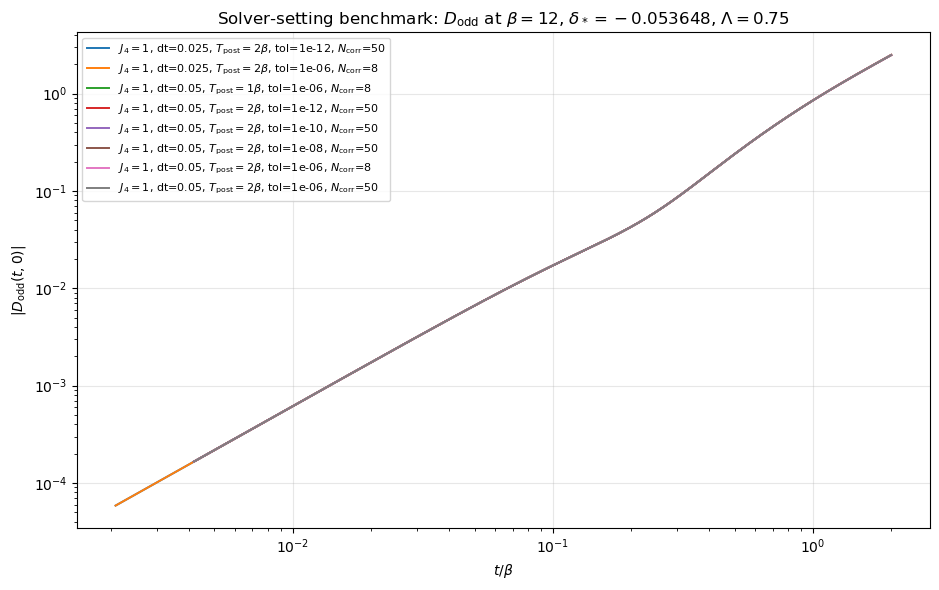

In [146]:
fig, ax = plt.subplots(figsize=(9.5, 6))

bench_cmap = plt.colormaps["tab10"]
bench_keys_sorted = sorted(bench_D_odd, key=lambda r: r["key"])

for i, run in enumerate(bench_keys_sorted):
    D_odd_abs = np.abs(run["D_odd"])
    keep = (run["t"] > 0) & (D_odd_abs >= 1e-14)  # t=0 excluded: Gc_complex has a pole there; drop |D_odd| below noise floor
    ax.plot(
        run["t"][keep] / run["beta"], D_odd_abs[keep],
        lw=1.4, color=bench_cmap(i % 10), label=bench_config_label(run["key"]),
    )

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|D_{\rm odd}(t,0)|$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(rf"Solver-setting benchmark: $D_{{\rm odd}}$ at $\beta={BENCH_BETA:g}$, "
             rf"$\delta_*={bench_delta:g}$, $\Lambda={bench_cutoff:g}$")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not bench_D_odd:
    print("No +/-lambda pairs available yet -- run more kbe-one jobs at this beta/(delta*,Lambda).")

### Fixed relative time: benchmark $D_{\rm odd}(T+\tau/2,\,T-\tau/2)$ vs centre time $T$

Same fixed-$\tau$, varying-$T$ construction as the earlier section, applied to the
benchmark pairs (`bench_pairs`) instead -- one curve per solver-setting combo, all at
$\beta=$ `BENCH_BETA`.

NameError: name 'bench_pairs' is not defined

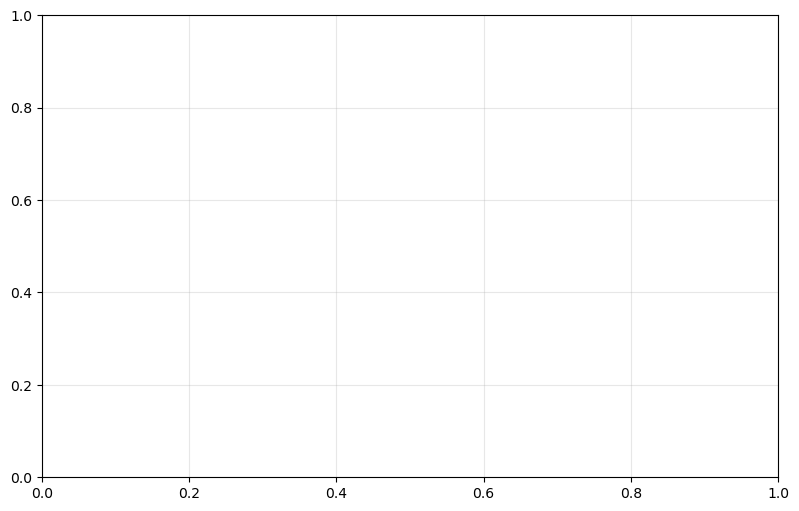

In [47]:
BENCH_TAU = 0.2  # fixed relative time; edit freely

fig, ax = plt.subplots(figsize=(9.5, 6))

bench_any_pair = False
for i, (key, sides) in enumerate(sorted(bench_pairs.items())):
    if not (1.0 in sides and -1.0 in sides):
        continue
    bench_any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]
    lam = abs(r_plus["eq_kernel_lambda"])
    tau = BENCH_TAU

    G_plus, G_minus = r_plus["G_lookup"], r_minus["G_lookup"]

    dt = float(np.nanmedian(np.diff(r_plus["t_Gt0"])))
    data_min, data_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    T_grid = np.arange(max(0.1, data_min + tau / 2), min(data_max, data_max - tau / 2), dt)

    G_plus_fixed_tau = np.array([G_plus(T + tau / 2, T - tau / 2) for T in T_grid])
    G_minus_fixed_tau = np.array([G_minus(T + tau / 2, T - tau / 2) for T in T_grid])
    D_odd_fixed_tau = (G_plus_fixed_tau - G_minus_fixed_tau) / (2 * lam * Gc_complex(tau, beta, J))

    # Reference value at the physical time T=beta, evaluated directly via the
    # G lookups (not a T_grid array index) so it lands on the same T=beta
    # regardless of dt.
    D_odd_ref = (
        (G_plus(beta + tau / 2, beta - tau / 2) - G_minus(beta + tau / 2, beta - tau / 2))
        / (2 * lam * Gc_complex(tau, beta, J))
    )

    y_vals = np.abs(D_odd_fixed_tau - D_odd_fixed_tau[-1])
    keep = y_vals >= 1e-14  # drop |D_odd| below noise floor
    ax.plot(
        T_grid[keep] / beta, y_vals[keep],
        lw=1.4, color=bench_cmap(i % 10), label=bench_config_label(key),
    )

ax.axvline(0.0, color="black", lw=1, ls=":")
ax.axvline(1.0, color="black", lw=1, ls="--")
ax.set_xlabel(r"$T/\beta$ (centre time)")
ax.set_ylabel(rf"$|D_{{\rm odd}}(T)-D_{{\rm odd}}(T=2\beta)|$, $\tau={BENCH_TAU:g}$")
ax.set_yscale("log")
ax.set_title(rf"Solver-setting benchmark: fixed-$\tau$ $D_{{\rm odd}}$ trace at $\beta={BENCH_BETA:g}$")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not bench_any_pair:
    print("No +/-lambda pairs available yet.")

### Fixed centre time: benchmark $D_{\rm odd}(T+\tau/2,\,T-\tau/2)$ vs relative time $\tau$

Same fixed-$T$, varying-$\tau$ construction as the earlier section, applied to the
benchmark pairs. $\tau$ starts just above $0$ since $G_c(\tau)$ has a pole there.

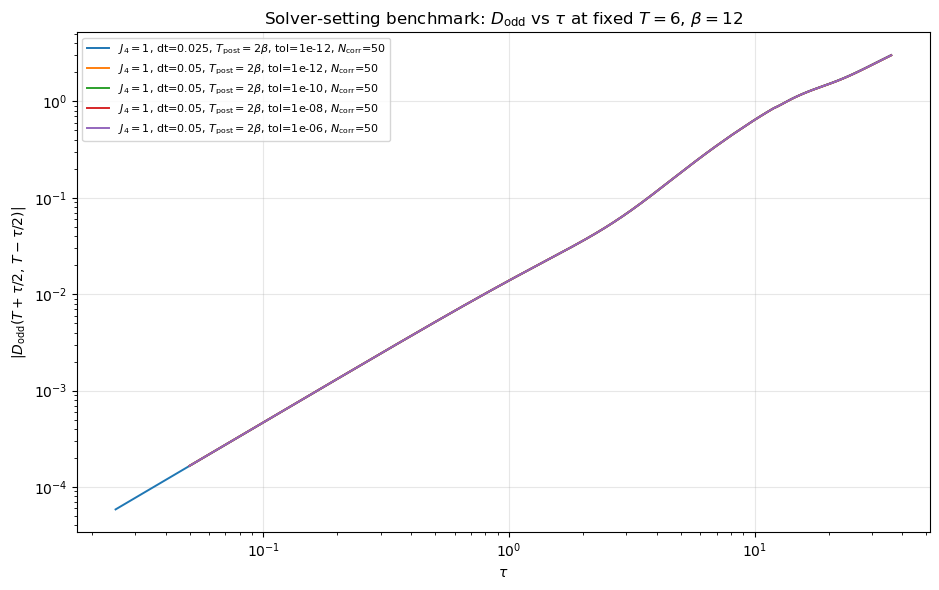

In [112]:
BENCH_T_FIXED = BENCH_BETA / 2  # fixed centre time; edit freely

fig, ax = plt.subplots(figsize=(9.5, 6))

bench_any_pair = False
for i, (key, sides) in enumerate(sorted(bench_pairs.items())):
    if not (1.0 in sides and -1.0 in sides):
        continue
    bench_any_pair = True

    r_plus, r_minus = sides[1.0], sides[-1.0]
    beta = r_plus["beta"]
    J = r_plus["J4_i"]
    lam = abs(r_plus["eq_kernel_lambda"])
    T_fixed = BENCH_T_FIXED

    G_plus, G_minus = r_plus["G_lookup"], r_minus["G_lookup"]

    dt = float(np.nanmedian(np.diff(r_plus["t_Gt0"])))
    data_min, data_max = r_plus["t_Gt0"][0], r_plus["t_Gt0"][-1]
    tau_max = 2 * min(T_fixed - data_min, data_max - T_fixed)
    tau_grid = np.arange(dt, tau_max, dt)  # starts just above 0: Gc_complex has a pole at tau=0

    G_plus_fixed_T = np.array([G_plus(T_fixed + tau / 2, T_fixed - tau / 2) for tau in tau_grid])
    G_minus_fixed_T = np.array([G_minus(T_fixed + tau / 2, T_fixed - tau / 2) for tau in tau_grid])
    D_odd_fixed_T = (G_plus_fixed_T - G_minus_fixed_T) / (2 * lam * Gc_complex(tau_grid, beta, J))

    D_odd_abs = np.abs(D_odd_fixed_T)
    keep = D_odd_abs >= 1e-14  # drop |D_odd| below noise floor
    ax.plot(tau_grid[keep], D_odd_abs[keep], lw=1.4, color=bench_cmap(i % 10), label=bench_config_label(key))

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$|D_{\rm odd}(T+\tau/2,\,T-\tau/2)|$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(rf"Solver-setting benchmark: $D_{{\rm odd}}$ vs $\tau$ at fixed $T={BENCH_T_FIXED:g}$, $\beta={BENCH_BETA:g}$")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

if not bench_any_pair:
    print("No +/-lambda pairs available yet.")